<a href="https://colab.research.google.com/github/ShivSubedi/Image_Analysis_LithiumIonBattery/blob/main/ImageAnalysis_LithiumIonBattery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This task offers practical experience in image analysis, utilizing core techniques such as edge detection, contour detection, and morphological operations to identify and isolate complex features, like spirals, in images (Example: CT scan image of a cross-sectional slice of cylindrical lithium-ion battery). It also explores geometric model fitting, applying circle and ellipse models to match contours and calculating residuals to evaluate the accuracy of the models, improving the ability to work with imperfect data.
You can download the image from the link:https://drive.google.com/file/d/1TYLNn-hlaEK3IiY8ht98ZRd_rf8MioXd/view?usp=sharing

Below are the tools and libraries used in this exercise:
1. OpenCV: for contour analysis and edge detection.
2. skimage: for image filtering and residual calculations.
3. NumPy: for array manipulations and mathematical computations.
4. imageio: to load and handle image data.

In [ ]:
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

##1. Load the image
Read the image as a grayscale numpy array. We will use the 'imageio' package for this task

In [6]:
# Read the PNG image in grayscale, use this if you have downloaded file in local pc and are running the script locally
img = iio.imread('/content/ImageAna_LiIonCell_CS.png', mode='F')
# Optionally, confirm the shape and datatype
print(img.shape)
print(img.dtype)

(1340, 1340)
float32


Confirm that a grayscale numpy array is loaded

In [7]:
assert isinstance(img, np.ndarray) #check if the object img is a numpy array, if not AssertionError is returned.
assert img.ndim == 2  # grayscale, so just x and y (no color channel)

Display the image in grayscale colormap

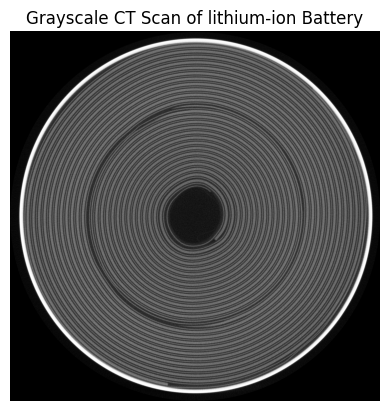

In [8]:
plt.imshow(img, cmap='gray')

plt.imshow(img, cmap='gray')
plt.title("Grayscale CT Scan of lithium-ion Battery")
plt.axis('off')  # Hide axis ticks
plt.show()

Above is an example of CT scan image cross-section slice of the lithium-ion battery. CT scan technology uses X-rays to image a target in 3D.
In the image:

1. Brighter pixels correspond to the stronger absorption of the X-rays, mostly with higher atomic number.
2. Stainless steel can: Appears as a bright ring due to iron's high atomic number.
3. Copper tabs: Visible as small bright lines.
4. Jellyroll: central spiral shape.
5. Cathode: Brighter than the anode (graphite) because of the higher atomic numbers of elements in NMC.

Since the image is of CT scan, each pixel in the image is in 3D. so henseforth we will refer each pixel as a voxel. Below is an example of voxel size in millimeters.

In [12]:
voxel_size_mm = 0.0165

##2. Line profile of the intensity values through the center of the image

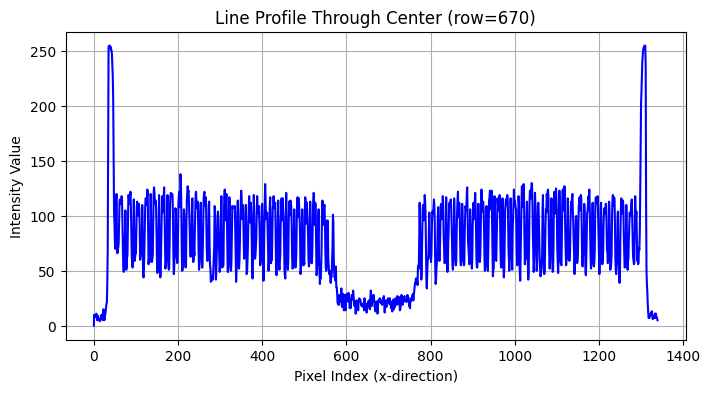

In [13]:
# Plottig the horizontal line profile
#Find the center of the image
center_row = img.shape[0] // 2
center_col = img.shape[1] // 2

# Extract the intensity values along the central row
line_profile = img[center_row, :]

# Plot the intensity profile
# Plot the line profile
plt.figure(figsize=(8, 4))
plt.plot(line_profile, color='blue')
plt.title(f'Line Profile Through Center (row={center_row})')
plt.xlabel('Pixel Index (x-direction)')
plt.ylabel('Intensity Value')
plt.grid(True)
plt.show()

Get a quick estimate of the diameter of this battery by recording the distance between the brightest peaks on the ends.

In [14]:
n_pixels_between_peaks = 1300  # replace with your estimate. can round to the nearest 100
print(f"Approximate battery diameter = {n_pixels_between_peaks * voxel_size_mm} mm")

Approximate battery diameter = 21.45 mm


Plot a linecut with the last 100 pixels of the previous line profile:

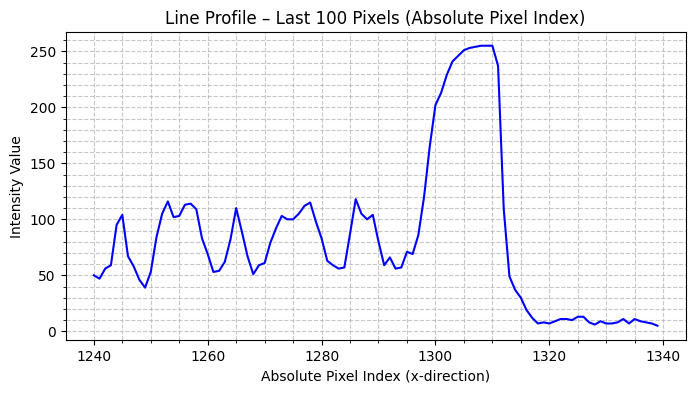

In [15]:
# Slice out the last 100 pixels of that line profile
last_100_pixels = line_profile[-100:]

# Calculate the absolute pixel indices for those last 100 pixels
start_index = line_profile.shape[0] - 100  # beginning of the last 100-pixel slice
end_index = line_profile.shape[0]         # end of that slice
x_vals = np.arange(start_index, end_index)  # absolute pixel indices

# Plot the last 100 pixels with absolute pixel indices on the x-axis
plt.figure(figsize=(8, 4))
plt.plot(x_vals, last_100_pixels, color='blue')
plt.title("Line Profile – Last 100 Pixels (Absolute Pixel Index)")
plt.xlabel("Absolute Pixel Index (x-direction)")
plt.ylabel("Intensity Value")
plt.minorticks_on()
plt.grid(which='both', linestyle='--', alpha=0.7)
plt.show()

Approximately how thick is the can wall (in mm)? Compare the image to the linecut to identify where the can wall starts and stops.

In [16]:
n_pixels_can_wall = 1312-1298  # replace with your estimate
print(f"Approximate can wall thickness = {n_pixels_can_wall * voxel_size_mm} mm")

Approximate can wall thickness = 0.231 mm


##3. Segmentation
Our next step is to segment the can from the image background. This involves creating a binary mask where the can appears as white and the rest of the image is black. This binary image will be used for subsequent measurements.

In [17]:
import cv2
from skimage import filters, morphology, measure

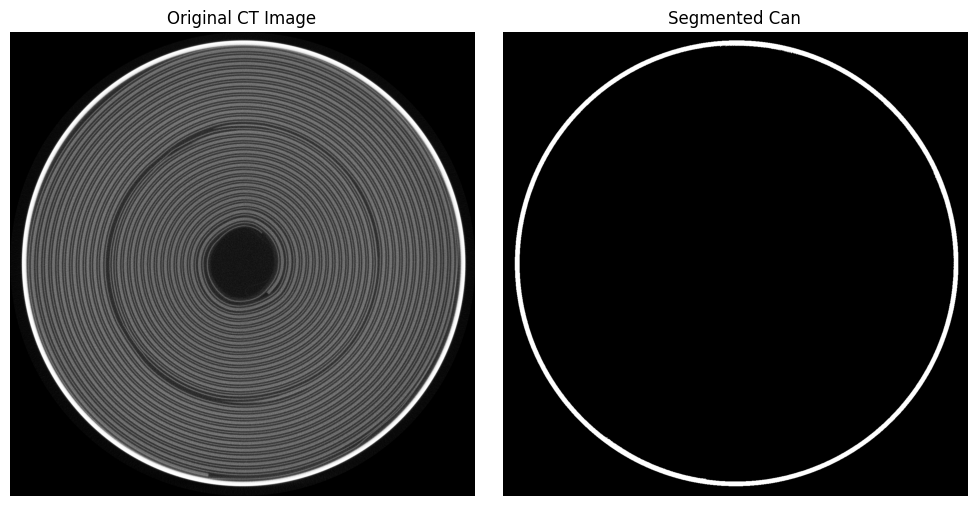

In [18]:
# binary = img > thresh
cutOFF_inten = img>130 #130 chosen from the line profile, which corresponds to max value of line profile other than can

# -----------------------------
# Remove small objects
# -----------------------------
# Adjust min_size so that small artifacts are removed, but the can remains
binary_clean = morphology.remove_small_objects(cutOFF_inten, min_size=1000)

can_binary_filtered= binary_clean

# -----------------------------
# Display results
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original CT Image")
axes[0].axis('off')

axes[1].imshow(can_binary_filtered, cmap='gray')
axes[1].set_title("Segmented Can")
axes[1].axis('off')

plt.tight_layout()
plt.show()


Assert that the array is Boolean

In [19]:
# Convert to boolean array
can_binary_filtered = can_binary_filtered.astype(bool)
assert can_binary_filtered.dtype == bool

## 4. Edge Detection
We will now use Canny edge detector to detect the ednges of the binary image of the can wall

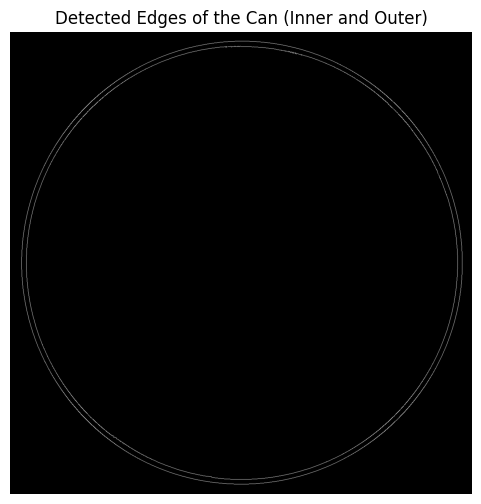

In [20]:
# Apply Canny edge detection with different thresholds to detect both inner and outer edges
#OpenCV’s Canny (cv2.Canny) expects an 8-bit image (0-255) of type uint8
#lower_th>potential edge, higher_th>strong edge, adjust these based on the image
#Note: Canny edge detection itself doesn’t know which edge is "inner" and which is "outer". It simply detects edges based on intensity gradients
#edges_oute and edges_inner labels are just place holder, it is upto user to identify them based on the image in test and plot generated
edges_outer = cv2.Canny(can_binary_filtered.astype(np.uint8) * 255, 50, 150)  # Outer edge detection
edges_inner = cv2.Canny(can_binary_filtered.astype(np.uint8) * 255, 10, 100)  # Inner edge detection

# Combine the results to highlight both inner and outer edges
combined_edges = cv2.bitwise_or(edges_outer, edges_inner)

# Display the combined edges
plt.figure(figsize=(6, 6))
plt.imshow(combined_edges, cmap='gray')
plt.title("Detected Edges of the Can (Inner and Outer)")
plt.axis('off')
plt.show()


The image you're viewing above displays two concentric rings, representing the inner and outer edges of the can. To isolate these rings for further analysis, we'll utilize the label function from skimage.measure. This function assigns unique integer labels to each connected region within the image. By identifying the labels corresponding to the inner and outer diameters, we can extract each ring into its own separate image.

This approach may require some manual inspection to correctly associate labels with the desired rings.

In [22]:
#Display number of rings detected and label assigned to corresponding ring

from skimage.measure import label, regionprops
from skimage.morphology import closing, disk

# Apply morphological closing to fill small gaps and remove noise
closed_edges = closing(combined_edges, disk(5))  # Use a disk-shaped structuring element

# Label connected components in the closed edge image
labeled_image, num_labels = label(closed_edges, connectivity=2, return_num=True)

# Analyze the labeled regions
regions = regionprops(labeled_image)

# Sort regions based on area (we assume the largest two regions are the inner and outer rings)
regions_sorted_by_area = sorted(regions, key=lambda x: x.area, reverse=True)

# Extract the two largest regions (likely corresponding to the outer and inner rings)
#I had to manually adjust [1] for outer ring and [0] for inner ring, other wise is miss labels them.
#Adjustment needed as sometimes inner ring might have largest area due to misc. regions.
outer_ring_label = regions_sorted_by_area[1].label  # Largest region (outer ring)
inner_ring_label = regions_sorted_by_area[0].label  # Second-largest region (inner ring)

# Create masks for the outer and inner rings
outer_ring_mask = np.zeros_like(labeled_image, dtype=np.uint8)
inner_ring_mask = np.zeros_like(labeled_image, dtype=np.uint8)

# Set the mask values for the outer and inner rings
#255 for ring and 0 for background
outer_ring_mask[labeled_image == outer_ring_label] = 255
inner_ring_mask[labeled_image == inner_ring_label] = 255

# # Convert masks to boolean dtype (True for ring, False for background)
# outer_ring_mask = outer_ring_mask.astype(bool)
# inner_ring_mask = inner_ring_mask.astype(bool)

# # Visualize the labeled image to check the region labels
# plt.figure(figsize=(6, 6))
# plt.imshow(labeled_image, cmap='nipy_spectral')
# plt.title("Labeled Image")
# plt.axis('off')
# plt.show()

#Print number of regions detected
print(f"Number of regions detected: {num_labels}")

# Print label information to check correctness
print(f"Outer ring label: {outer_ring_label}")
print(f"Inner ring label: {inner_ring_label}")

Number of regions detected: 2
Outer ring label: 1
Inner ring label: 2


Plot the inner and outer rings in two separate figures

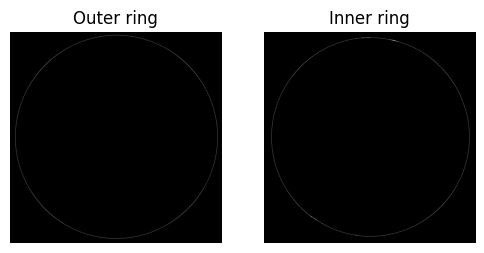

In [23]:
# Display the extracted outer and inner rings
plt.figure(figsize=(6, 6))

# Plot the outer ring
plt.subplot(1, 2, 1)
plt.imshow(outer_ring_mask, cmap='gray')
plt.title("Outer ring")
plt.axis('off')

# Plot the inner ring
plt.subplot(1, 2, 2)
plt.imshow(inner_ring_mask, cmap='gray')
plt.title("Inner ring")
plt.axis('off')

plt.show()


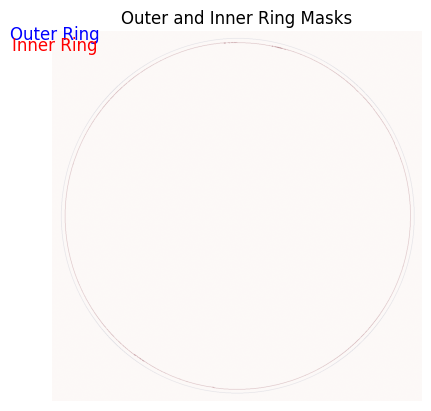

In [24]:
#confirming that outer and inner ring are plotted as expected

# Plot the outer ring mask (labeled as "Outer Ring")
plt.imshow(outer_ring_mask, cmap='Blues', alpha=0.5)  # Set alpha to make it semi-transparent
plt.title("Outer and Inner Ring Masks")
plt.axis('off')

# Plot the inner ring mask (labeled as "Inner Ring")
plt.imshow(inner_ring_mask, cmap='Reds', alpha=0.5)  # Set alpha to make it semi-transparent

# Label the areas
plt.text(10, 10, 'Outer Ring', color='blue', fontsize=12, ha='center', va='center')
plt.text(10, 50, 'Inner Ring', color='red', fontsize=12, ha='center', va='center')

# Show the plot
plt.show()

## 5. Measurement of Can diameter
We will now measure the inner and outer diameter of the can using the CircleModel feature of skimage

In [25]:
from skimage.measure import CircleModel

# Extract coordinates for the outer and inner rings
outer_coords = np.column_stack(np.where(outer_ring_mask == 255))
print(f"Number of points in outer ring mask: {len(outer_coords)}")

inner_coords = np.column_stack(np.where(inner_ring_mask == 255))
print(f"Number of points in inner ring mask: {len(inner_coords)}")

Number of points in outer ring mask: 4208
Number of points in inner ring mask: 4267


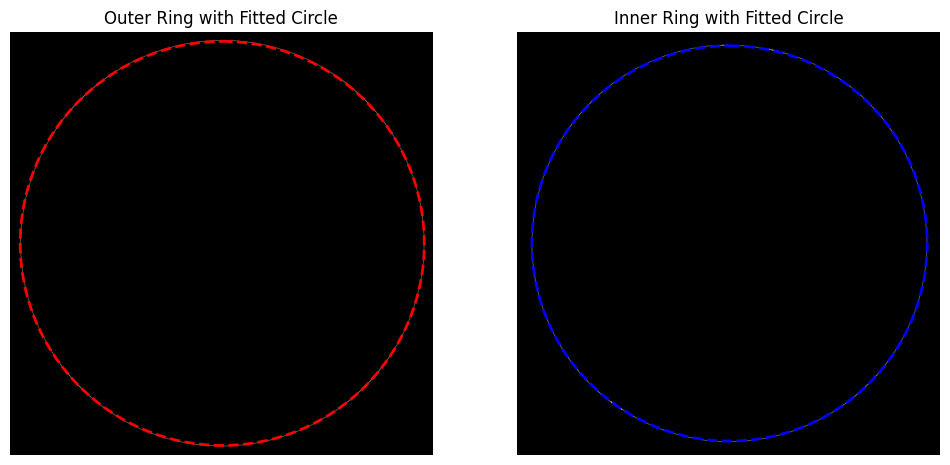

In [26]:
# Fit the CircleModel to the outer ring (directly applying CircleModel)
outer_circle_model = CircleModel()
outer_fit_success = outer_circle_model.estimate(outer_coords)  # Fit the circle to the outer ring

# Fit the CircleModel to the inner ring (directly applying CircleModel)
inner_circle_model = CircleModel()
inner_fit_success = inner_circle_model.estimate(inner_coords)  # Fit the circle to the inner ring

# Plot the outer ring with the fitted circle
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot outer ring mask and fitted circle
ax[0].imshow(outer_ring_mask, cmap='gray')
if outer_fit_success:
    # Plot the fitted circle (no extraction of parameters yet)
    circle_outer = plt.Circle((outer_circle_model.params[1], outer_circle_model.params[0]),
                              outer_circle_model.params[2], color='r', fill=False, linestyle='--', linewidth=2)
    ax[0].add_artist(circle_outer)
ax[0].set_title("Outer Ring with Fitted Circle")
ax[0].axis('off')

# Plot inner ring mask and fitted circle
ax[1].imshow(inner_ring_mask, cmap='gray')
if inner_fit_success:
    # Plot the fitted circle (no extraction of parameters yet)
    circle_inner = plt.Circle((inner_circle_model.params[1], inner_circle_model.params[0]),
                              inner_circle_model.params[2], color='b', fill=False, linestyle='--', linewidth=2)
    ax[1].add_artist(circle_inner)
ax[1].set_title("Inner Ring with Fitted Circle")
ax[1].axis('off')

# Display the plots
plt.show()

Estimate the inner and outer radii of the can

In [27]:
#Extract the radii from the fitted circle models using the params attribute
outer_radius_pixels = outer_circle_model.params[2]  # Radius in pixels
inner_radius_pixels = inner_circle_model.params[2]  # Radius in pixels

# Convert the radii to millimeters
outer_radius_circleModel_mm = outer_radius_pixels * voxel_size_mm  # Convert to millimeters
inner_radius_circleModel_mm = inner_radius_pixels * voxel_size_mm  # Convert to millimeters

print(f"Outer radius: {outer_radius_circleModel_mm:.2f} mm")
print(f"Inner radius: {inner_radius_circleModel_mm:.2f} mm")

Outer radius: 10.57 mm
Inner radius: 10.34 mm


Sanity check: confirm inner radius < outer radius

In [29]:
assert inner_radius_circleModel_mm < outer_radius_circleModel_mm

Plot the residuals of the fit

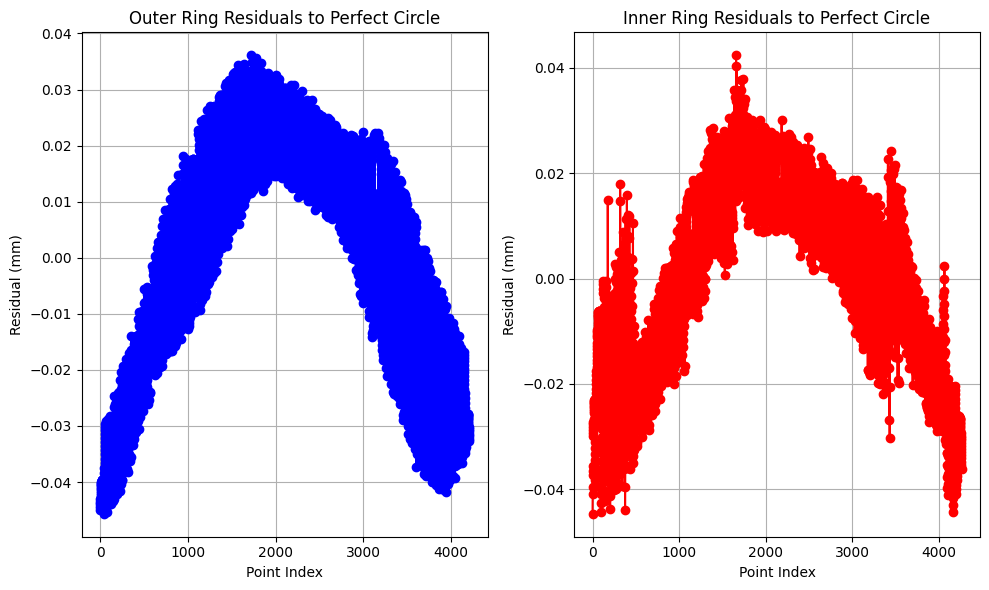

In [30]:
#Step1: Calculate the residuals for each point (i.e., the difference between the actual distance of each point from the fitted circle and the expected radius of the fitted circle)
#Step 2: Plot the residuals with respect to the index of each point (or the angle/position of the point on the circle).

def calculate_residuals(coords, circle_model):
    residuals = circle_model.residuals(coords)
    return residuals

# Calculate residuals for the outer and inner rings
outer_residuals_circleModel = calculate_residuals(outer_coords, outer_circle_model)
inner_residuals_circleModel = calculate_residuals(inner_coords, inner_circle_model)

outer_residuals_circleModel_mm=outer_residuals_circleModel*voxel_size_mm
inner_residuals_circleModel_mm=inner_residuals_circleModel*voxel_size_mm


# Plot residuals for the outer ring
plt.figure(figsize=(10, 6))

# Plot for outer ring residuals
plt.subplot(1, 2, 1)
plt.plot(outer_residuals_circleModel_mm, marker='o', color='blue')
plt.title('Outer Ring Residuals to Perfect Circle')
plt.xlabel('Point Index')
plt.ylabel('Residual (mm)')
plt.grid(True)

# Set zoom-in range for y-axis (adjust according to your residuals)
# plt.xlim(0, 200)  # Zoom into the residuals range between 0 and 1 (for example)

# Plot for inner ring residuals
plt.subplot(1, 2, 2)
plt.plot(inner_residuals_circleModel_mm, marker='o', color='red')
plt.title('Inner Ring Residuals to Perfect Circle')
plt.xlabel('Point Index')
plt.ylabel('Residual (mm)')
plt.grid(True)
# Set zoom-in range for y-axis (adjust according to your residuals)
# plt.xlim(0, 200)  # Zoom into the residuals range between 0 and 1 (for example)

plt.tight_layout()
plt.show()

## 6. Measurement of 'Can' thickness

In [33]:
can_wall_thickness_mm = outer_radius_circleModel_mm - inner_radius_circleModel_mm
print(f"can_wall_thickness_mm: {can_wall_thickness_mm:.2f} mm")

can_wall_thickness_mm: 0.23 mm


Comparison: the can wall thickness obtained from the line profile and from fit of circleModel are very close


## 7. Concentricity of the radii
Concentricity measures the distance between centroids of the inner and outer circles.
Ideal concentricity is zero

In [35]:
# Extract the inner and outer regions based on labels
inner_region = next(region for region in regions if region.label == inner_ring_label)
outer_region = next(region for region in regions if region.label == outer_ring_label)

# Extract the centroids (y, x) coordinates
inner_centroid = inner_region.centroid  # (y, x) for the inner region
outer_centroid = outer_region.centroid  # (y, x) for the outer region

# Calculate the Euclidean distance between the two centroids
distance = np.sqrt((outer_centroid[0] - inner_centroid[0])**2 + (outer_centroid[1] - inner_centroid[1])**2)

distance_mm = distance** voxel_size_mm

# Print the distance
print(f"Distance between the centroids of the inner and outer rings: {distance_mm:.2f} mm")

Distance between the centroids of the inner and outer rings: 1.04 mm


Normalized concentricity = (concentricity/ diameter of the outer edge of the circle) * 100 %

In [39]:
#Concentricity refers to how well two circles (or rings) share the same center.
Average_radius_mm=(outer_radius_circleModel_mm+ inner_radius_circleModel_mm)/2

concentricity=distance_mm/Average_radius_mm
normalized_concentricity_percent = (concentricity/(outer_radius_circleModel_mm*2))*100
print(f"normalized_concentricity_percent: {normalized_concentricity_percent:.2f} %")

normalized_concentricity_percent: 0.47 %


## 8. Circularity Measurement
i.e., How close are the inner and outer edges to perfect circles?

We'll measure their circularity, which is a value between 0 and 1 (or 0% and 100%). A value of 1 (100%) indicates a perfect circle.

To calculate circularity, we'll use the EllipseModel function from scikit-image to fit an ellipse to each edge. We'll then take the ratio of the minor diameter (d_min) to the major diameter (d_max) of the fitted ellipse and multiply by 100% to express it as a percentage.

This will give us a quantitative measure of how closely each edge resembles a perfect circle.

In [40]:
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse  # Import Ellipse from patches
def calculate_circularity(coords):
    """ Calculate the circularity based on ellipse fitting (d_min / d_max) """
    # Fit an ellipse to the points
    ellipse_model = EllipseModel()
    ellipse_model.estimate(coords)  # Fit the ellipse to the coordinates

    # Extract the minor and major axes (d_min and d_max)
    d_min = min(ellipse_model.params[2], ellipse_model.params[3])  # Minor axis (smaller value)
    d_max = max(ellipse_model.params[2], ellipse_model.params[3])  # Major axis (larger value)

    # Calculate circularity
    circularity = d_min / d_max
    return circularity

# Fit an ellipse to the outer ring and calculate its circularity
outer_ellipse_model = EllipseModel()
outer_ellipse_model.estimate(outer_coords)
circularity_outer = calculate_circularity(outer_coords)

# Fit an ellipse to the inner ring and calculate its circularity
inner_ellipse_model = EllipseModel()
inner_ellipse_model.estimate(inner_coords)
circularity_inner = calculate_circularity(inner_coords)

# Print the results
print(f"Inner ring circularity: {circularity_inner:.4f}")
print(f"Outer ring circularity: {circularity_outer:.4f}")

Inner ring circularity: 0.9959
Outer ring circularity: 0.9948


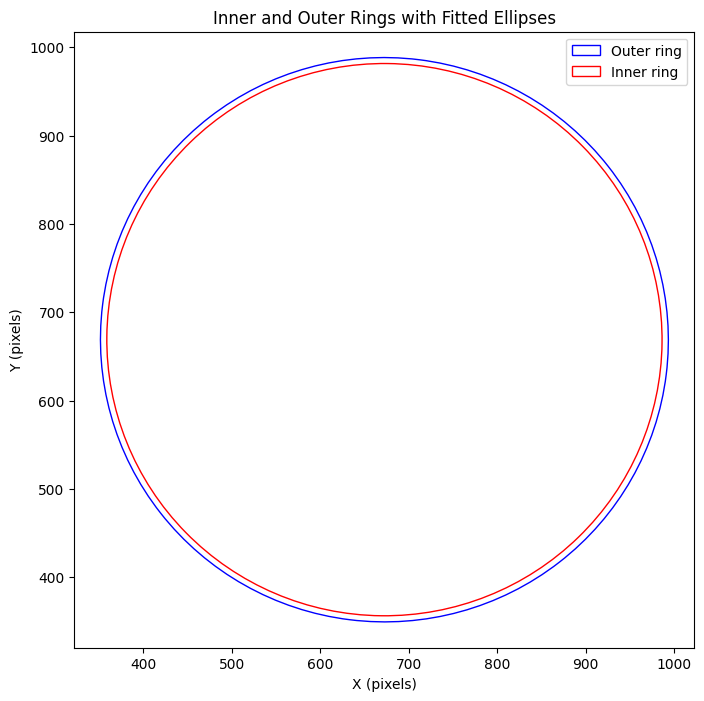

In [41]:
# Optionally, plot the fitted ellipses for both the inner and outer rings
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the fitted ellipse for the outer ring
ax.add_patch(Ellipse((outer_ellipse_model.params[1], outer_ellipse_model.params[0]),
                     width=outer_ellipse_model.params[2], height=outer_ellipse_model.params[3],
                     angle=outer_ellipse_model.params[4] * 180 / np.pi, color='blue', fill=False, label="Outer ring"))

# Plot the fitted ellipse for the inner ring
ax.add_patch(Ellipse((inner_ellipse_model.params[1], inner_ellipse_model.params[0]),
                     width=inner_ellipse_model.params[2], height=inner_ellipse_model.params[3],
                     angle=inner_ellipse_model.params[4] * 180 / np.pi, color='red', fill=False, label="Inner ring"))

ax.set_title("Inner and Outer Rings with Fitted Ellipses")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
ax.legend()
plt.axis('equal')
plt.show()

Plot the residuals from the the ellipse model

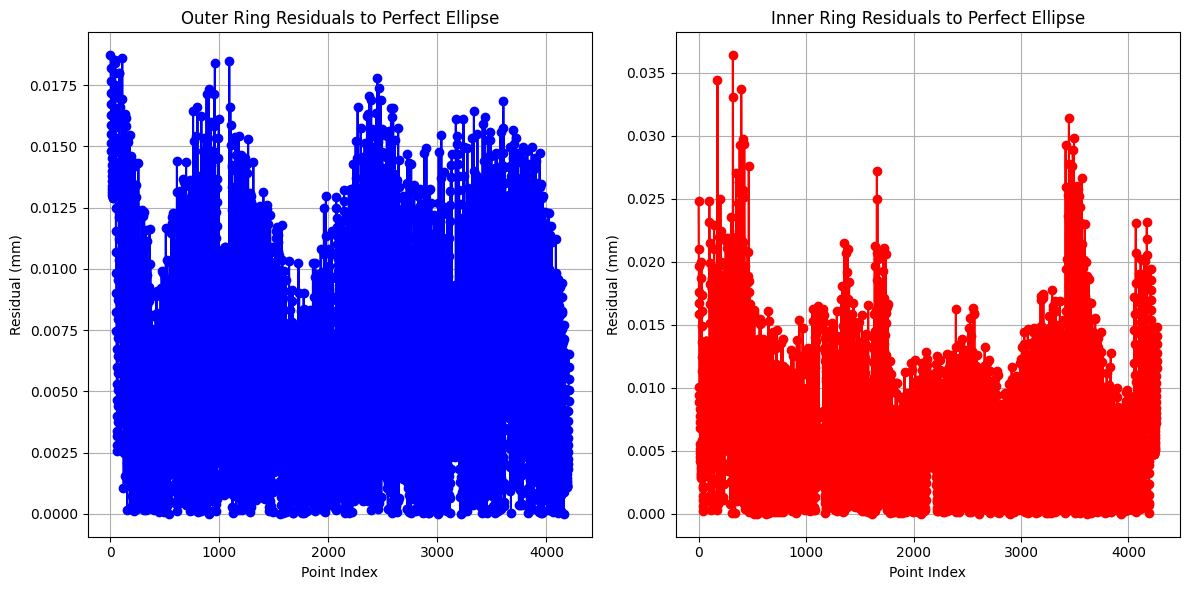

In [44]:
def calculate_residuals(coords, ellipse_model):

    # Calculate residuals
    residuals = ellipse_model.residuals(coords)

    return residuals

# Fit an ellipse to the outer ring
outer_ellipse_model = EllipseModel()
outer_ellipse_model.estimate(outer_coords)
outer_residuals_ellipseModel = calculate_residuals(outer_coords, outer_ellipse_model)

# Fit an ellipse to the inner ring
inner_ellipse_model = EllipseModel()
inner_ellipse_model.estimate(inner_coords)
inner_residuals_ellipseModel = calculate_residuals(inner_coords, inner_ellipse_model)

#Expressing outer and inner_residuals in mm
outer_residuals_ellipseModel_mm=outer_residuals_ellipseModel*voxel_size_mm
inner_residuals_ellipseModel_mm=inner_residuals_ellipseModel*voxel_size_mm

# Plot residuals for the outer ring
plt.figure(figsize=(12, 6))

# Plot for outer ring residuals
plt.subplot(1, 2, 1)
plt.plot(outer_residuals_ellipseModel_mm, marker='o', linestyle='-', color='blue')
plt.title('Outer Ring Residuals to Perfect Ellipse')
plt.xlabel('Point Index')
plt.ylabel('Residual (mm)')
plt.grid(True)

# Plot for inner ring residuals
plt.subplot(1, 2, 2)
plt.plot(inner_residuals_ellipseModel_mm, marker='o', linestyle='-', color='red')
plt.title('Inner Ring Residuals to Perfect Ellipse')
plt.xlabel('Point Index')
plt.ylabel('Residual (mm)')
plt.grid(True)

plt.tight_layout()
plt.show()